# 🏥 Projet : Classification du Diagnostic du Cancer du Sein
## 🎓 Filière : ADIA – IISE (Université Ibnou Zohr)
### 📝 Module : Intelligence Artificielle

---

**Élaboré par :**
* 👤 **Malak el yaagoubi**
* 👤 **hajar kaoukab**

---

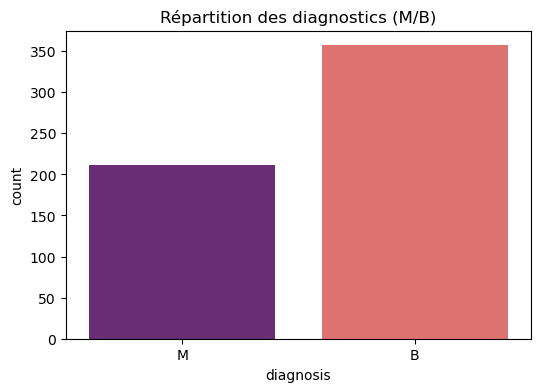

In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Breast Cancer Wisconsin (1).csv')

df = df.drop(['id', 'Unnamed: 32'], axis=1, errors='ignore')

plt.figure(figsize=(6,4))
sns.countplot(x='diagnosis', data=df, palette='magma')
plt.title('Répartition des diagnostics (M/B)')
plt.show()

**Explication de l'Étape 1 :**
* Nous avons chargé les données à l'aide de `pandas`.
* Nous avons supprimé les colonnes `id` et `Unnamed: 32` car elles n'apportent aucune information utile au diagnostic.
* Nous avons affiché un graphique pour voir la distribution des tumeurs malignes et bénignes.


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print("Prétraitement terminé avec succès !")
print(f"Taille de X_train : {X_train.shape}")

Prétraitement terminé avec succès !
Taille de X_train : (455, 30)


**Explication de l'Étape 2 :**
* Nous avons transformé la colonne `diagnosis` en chiffres (1 et 0) pour que les modèles puissent faire des calculs.
* Nous avons divisé le dataset en deux parties : une pour l'entraînement et une pour le test.
* Nous avons appliqué le `StandardScaler` pour mettre toutes les caractéristiques sur la même échelle.


In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"Modèle {name} entraîné.")

Modèle Logistic Regression entraîné.
Modèle KNN entraîné.
Modèle Decision Tree entraîné.


**Explication des Étapes 3 & 4 :**
* Nous avons choisi trois algorithmes différents pour comparer leurs résultats.
* Nous avons utilisé la méthode `.fit()` pour entraîner chaque modèle sur les données d'apprentissage.


In [5]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"\n--- Résultats pour {name} ---")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(classification_report(y_test, y_pred))


--- Résultats pour Logistic Regression ---
Accuracy: 0.9737
              precision    recall  f1-score   support

           0       0.97      0.99      0.98        71
           1       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114


--- Résultats pour KNN ---
Accuracy: 0.9474
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        71
           1       0.93      0.93      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114


--- Résultats pour Decision Tree ---
Accuracy: 0.9386
              precision    recall  f1-score   support

           0       0.94      0.96      0.95        71
           1       0.93      0.91      0.92        43

    accuracy         

**Explication de l'Étape 5 :**
* Nous avons testé les modèles sur les données de test.
* L'Accuracy nous donne le pourcentage de bonnes prédictions.
* Le `classification_report` affiche la précision, le rappel et le score F1 pour chaque classe.


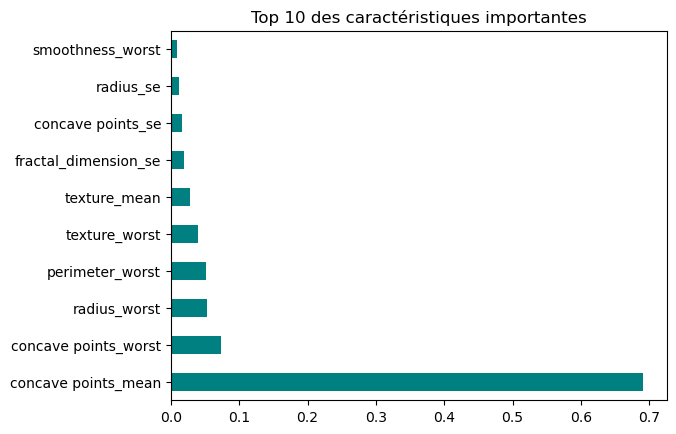

In [6]:
dt_model = models["Decision Tree"]
importance = pd.Series(dt_model.feature_importances_, index=X.columns)

importance.nlargest(10).plot(kind='barh', color='teal')
plt.title('Top 10 des caractéristiques importantes')
plt.show()

**Explication de l'Étape 6 :**
* Nous avons analysé quelles caractéristiques cliniques influencent le plus la décision du modèle.
* Le graphique montre les 10 facteurs les plus déterminants pour identifier une tumeur maligne.


In [7]:
def diagnostic_manuel(nouvelles_mesures):
    mesures_std = scaler.transform([nouvelles_mesures])
    pred = models["Logistic Regression"].predict(mesures_std)
    return "Maligne (M)" if pred[0] == 1 else "Bénigne (B)"
    
exemple = X.iloc[0].values
print(f"Prédiction pour l'exemple : {diagnostic_manuel(exemple)}")

Prédiction pour l'exemple : Maligne (M)


**Explication de l'Étape 7 :**
* Nous avons créé une fonction qui permet de tester le système avec de nouvelles données.
* Cette étape démontre comment le projet peut être utilisé concrètement par un médecin.
